

> Add blockquote
# OrderPulse — E-Commerce Delivery & Customer Satisfaction Analytics

## Objective
Analyze e-commerce orders to identify late-delivery patterns,
customer satisfaction drivers, seller performance, and
at-risk orders.

## Tools
Python | Pandas | SQL | Power BI | Machine Learning


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os
zip_path="/content/archive.zip"
extract_path="/content/archive"
with zipfile.ZipFile(zip_path,"r") as zip_ref:
  zip_ref.extractall(extract_path)
  print("Dataset extracted sucesfully")

Dataset extracted sucesfully


In [ ]:
os.listdir(extract_path)

['olist_orders_dataset.csv',
 'product_category_name_translation.csv',
 'olist_geolocation_dataset.csv',
 'olist_order_payments_dataset.csv',
 'olist_products_dataset.csv',
 'olist_sellers_dataset.csv',
 'olist_customers_dataset.csv',
 'olist_order_reviews_dataset.csv',
 'olist_order_items_dataset.csv']

In [ ]:
import pandas as pd
import os
orders=pd.read_csv(
    os.path.join(extract_path, 'olist_orders_dataset.csv')
    )
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders.shape

(99441, 8)

In [ ]:
orders.size

795528

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
date_columns=['order_purchase_timestamp','order_approved_at','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

In [ ]:
date_columns=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")


In [ ]:
orders.dtypes

,0
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]


In [ ]:
orders["delivery_delay_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days

In [ ]:
orders[[
    "order_id",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "delivery_delay_days"
]].head(10)

,order_id,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-10 21:25:13,2017-10-18,-8.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-08-07 15:27:45,2018-08-13,-6.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-17 18:06:29,2018-09-04,-18.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-12-02 00:28:42,2017-12-15,-13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-16 18:17:02,2018-02-26,-10.0
5,a4591c265e18cb1dcee52889e2d8acc3,2017-07-26 10:57:55,2017-08-01,-6.0
6,136cce7faa42fdb2cefd53fdc79a6098,NaT,2017-05-09,NaN
7,6514b8ad8028c9f2cc2374ded245783f,2017-05-26 12:55:51,2017-06-07,-12.0
8,76c6e866289321a7c93b82b54852dc33,2017-02-02 14:08:10,2017-03-06,-32.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,2017-08-16 17:14:30,2017-08-23,-7.0


In [ ]:
import numpy as np
orders["delivery_status"]=np.select(
    [
        orders["delivery_delay_days"].isna(),
orders["delivery_delay_days"]<0,
orders["delivery_delay_days"] ==0,
    orders["delivery_delay_days"]>0,
    ],
    [
        "not delivered",
        "Early",
        "On Time",
        "Late"
    ],
    default="Unkown"
)



In [ ]:
orders["delivery_status"].value_counts()

,count
delivery_status,
Early,88649
Late,6535
not delivered,2965
On Time,1292


In [ ]:
orders["delivery_status"].value_counts(dropna=False)

,count
delivery_status,
Early,88649
Late,6535
not delivered,2965
On Time,1292


In [ ]:
delivered = orders[orders["delivery_delay_days"].notna()]

on_time_business = delivered[
    delivered["delivery_delay_days"] <= 0
]

print("Delivered orders:", len(delivered))
print("On-time orders:", len(on_time_business))
print(
    "On-time delivery rate:",
    round(len(on_time_business) / len(delivered) * 100, 2),
    "%"
)

Delivered orders: 96476
On-time orders: 89941
On-time delivery rate: 93.23 %


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'archive.zip', 'archive', 'drive', 'sample_data']


In [ ]:
reviews = pd.read_csv(
    "/content/archive/olist_order_reviews_dataset.csv"
)

reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
reviews.shape

(99224, 7)

In [ ]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
order_reviews = orders.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [ ]:
order_reviews[
    [
        "order_id",
        "delivery_delay_days",
        "delivery_status",
        "review_score"
    ]
].head(10)

,order_id,delivery_delay_days,delivery_status,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,-8.0,Early,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,-6.0,Early,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,-18.0,Early,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,Early,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,-10.0,Early,5.0
5,a4591c265e18cb1dcee52889e2d8acc3,-6.0,Early,4.0
6,136cce7faa42fdb2cefd53fdc79a6098,NaN,not delivered,2.0
7,6514b8ad8028c9f2cc2374ded245783f,-12.0,Early,5.0
8,76c6e866289321a7c93b82b54852dc33,-32.0,Early,1.0
9,e69bfb5eb88e0ed6a785585b27e16dbf,-7.0,Early,5.0


In [ ]:
rating_by_status = (
    order_reviews
    .groupby("delivery_status")["review_score"]
    .agg(["count", "mean"])
    .round(2)
)

rating_by_status

,count,mean
delivery_status,,
Early,88658,4.29
Late,6410,2.27
On Time,1291,4.03
not delivered,2865,1.76


In [ ]:
late_orders = order_reviews[
    order_reviews["delivery_delay_days"] > 0
].copy()

late_orders["delay_bucket"] = pd.cut(
    late_orders["delivery_delay_days"],
    bins=[0, 1, 3, 7, 14, float("inf")],
    labels=[
        "1 day",
        "2–3 days",
        "4–7 days",
        "8–14 days",
        "15+ days"
    ]
)

delay_impact = (
    late_orders
    .groupby("delay_bucket", observed=True)["review_score"]
    .agg(["count", "mean"])
    .round(2)
)

delay_impact

,count,mean
delay_bucket,,
1 day,823,3.73
2–3 days,1033,2.94
4–7 days,1756,2.10
8–14 days,1453,1.68
15+ days,1345,1.72


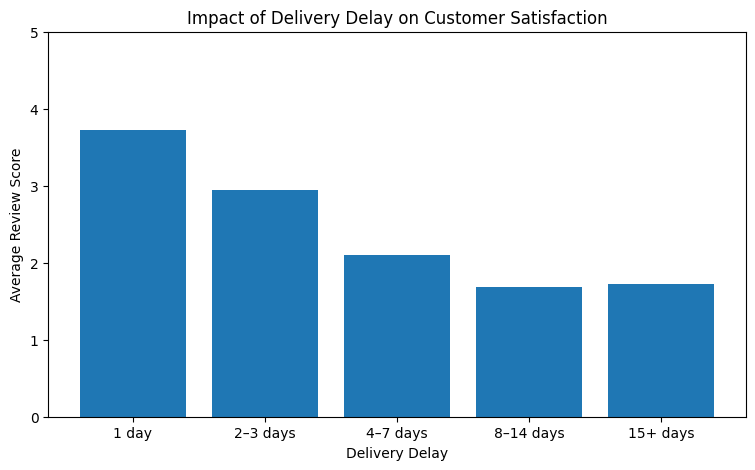

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    delay_impact.index.astype(str),
    delay_impact["mean"]
)

plt.xlabel("Delivery Delay")
plt.ylabel("Average Review Score")
plt.title("Impact of Delivery Delay on Customer Satisfaction")

plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.show()

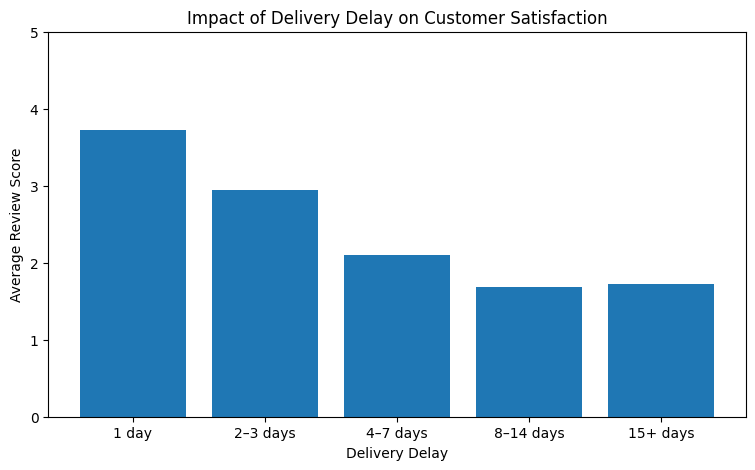

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,5))
plt.bar(
    delay_impact.index.astype(str),
    delay_impact["mean"]
)
plt.xlabel("Delivery Delay")
plt.ylabel("Average Review Score")
plt.title("Impact of Delivery Delay on Customer Satisfaction")
plt.ylim(0,5)
plt.xticks(rotation=0)
plt.show()

In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file == "olist_sellers_dataset.csv":
            print(os.path.join(root, file))

/content/archive/olist_sellers_dataset.csv


In [ ]:
sellers = pd.read_csv(
    "/content/archive/olist_sellers_dataset.csv"
)

sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
sellers.shape

(3095, 4)

In [ ]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [ ]:
order_items = pd.read_csv(
    "/content/archive/olist_order_items_dataset.csv"
)

order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items.shape

(112650, 7)

In [ ]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
order_items["shipping_limit_date"]=pd.to_datetime(
    order_items["shipping_limit_date"],
    errors="coerce"
)

In [ ]:
order_items.dtypes

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,datetime64[ns]
price,float64
freight_value,float64


In [ ]:
seller_orders=order_items.merge(
    sellers,
    on="seller_id",
    how="left"
)

In [ ]:
seller_orders.shape

(112650, 10)

In [ ]:
seller_orders.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,27277,volta redonda,SP
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,3471,sao paulo,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,37564,borda da mata,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,14403,franca,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,87900,loanda,PR


In [ ]:
seller_orders=seller_orders.merge(
    orders[[
    "order_id",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "delivery_delay_days"
]],
    on="order_id",
    how="left")


In [ ]:
seller_orders.shape

(112650, 13)

In [ ]:
seller_orders.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_delay_days']

In [ ]:
seller_orders = seller_orders.merge(
    orders[
        [
            "order_id",
            "order_status",
            "order_delivered_customer_date",
            "order_estimated_delivery_date",
            "delivery_delay_days",
            "delivery_status"
        ]
    ],
    on="order_id",
    how="left"
)

In [ ]:
import numpy as np

seller_orders["delivery_status"] = np.select(
    [
        seller_orders["delivery_delay_days_y"].isna(),
        seller_orders["delivery_delay_days_y"] < 0,
        seller_orders["delivery_delay_days_y"] == 0,
        seller_orders["delivery_delay_days_y"] > 0
    ],
    [
        "Not Delivered",
        "Early",
        "On Time",
        "Late"
    ],
    default="Unknown"
)
print("delivery_delay_days_y" in seller_orders.columns)

True


In [ ]:
print(seller_orders.columns.tolist())

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'order_delivered_customer_date_x', 'order_estimated_delivery_date_x', 'delivery_delay_days_x', 'order_status', 'order_delivered_customer_date_y', 'order_estimated_delivery_date_y', 'delivery_delay_days_y', 'delivery_status']


In [ ]:
print("seller_orders.columns.tolist()")

seller_orders.columns.tolist()


In [ ]:
seller_orders[
    [
        "order_id",
        "seller_id",
        "price",
        "delivery_delay_days_y",
        "delivery_status"


    ]
].head(10)

,order_id,seller_id,price,delivery_delay_days_y,delivery_status
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,58.90,-9.0,Early
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,239.90,-3.0,Early
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,199.00,-14.0,Early
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,12.99,-6.0,Early
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,199.90,-16.0,Early
5,00048cc3ae777c65dbb7d2a0634bc1ea,6426d21aca402a131fc0a5d0960a3c90,21.90,-15.0,Early
6,00054e8431b9d7675808bcb819fb4a32,7040e82f899a04d1b434b795a43b4617,19.90,-17.0,Early
7,000576fe39319847cbb9d288c5617fa6,5996cddab893a4652a15592fb58ab8db,810.00,-16.0,Early
8,0005a1a1728c9d785b8e2b08b904576c,a416b6a846a11724393025641d4edd5e,145.95,0.0,On Time
9,0005f50442cb953dcd1d21e1fb923495,ba143b05f0110f0dc71ad71b4466ce92,53.99,-19.0,Early


In [ ]:
seller_orders.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'order_delivered_customer_date_x',
 'order_estimated_delivery_date_x',
 'delivery_delay_days_x',
 'order_status',
 'order_delivered_customer_date_y',
 'order_estimated_delivery_date_y',
 'delivery_delay_days_y',
 'delivery_status']

In [ ]:
sellers_orders=seller_orders.drop(
    columns=[
        "delivery_delay_days_x",
        "order_delivered_customer_date_x",
        "order_estimated_delivery_date_x"
    ]
)

In [ ]:
seller_orders=seller_orders.drop(
    columns=[
        "delivery_delay_days_x",
        "order_delivered_customer_date_x",
        "order_estimated_delivery_date_x"
    ]
)

In [ ]:
seller_orders=seller_orders.rename(
    columns={
        "delivery_delay_days_y":"delivery_delay_days",
        "order_delivered_customer_date_y":"order_delivered_customer_date",
        "order_estimated_delivery_date_y":"order_estimated_delivery_date"
    }
)

In [ ]:
seller_orders.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'order_status',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_delay_days',
 'delivery_status']

In [ ]:
seller_scorecard=(
    seller_orders
    .groupby("seller_id")
    .agg(
        total_orders=("order_id","nunique"),
        revenue=("price","sum"),
        avg_delivery_date=("delivery_delay_days","mean"),
        late_orders=("delivery_status",lambda x:(x=="Late").sum())

    )
    .reset_index()
)

In [ ]:
seller_scorecard["late_delivery_pct"]=(
    seller_scorecard["late_orders"]
    /seller_scorecard["total_orders"]*100


).round(2)

In [ ]:
seller_scorecard.head(10)

,seller_id,total_orders,revenue,avg_delivery_date,late_orders,late_delivery_pct
0,0015a82c2db000af6aaaf3ae2ecb0532,3,2685.00,-16.333333,0,0.00
1,001cca7ae9ae17fb1caed9dfb1094831,200,25080.03,-13.213675,12,6.00
2,001e6ad469a905060d959994f1b41e4f,1,250.00,NaN,0,0.00
3,002100f778ceb8431b7a1020ff7ab48f,51,1234.50,-8.185185,9,17.65
4,003554e2dce176b5555353e4f3555ac8,1,120.00,-27.000000,0,0.00
5,004c9cd9d87a3c30c522c48c4fc07416,158,19712.71,-11.982143,10,6.33
6,00720abe85ba0859807595bbf045a33b,13,1007.50,-12.730769,2,15.38
7,00ab3eff1b5192e5f1a63bcecfee11c8,1,98.00,-10.000000,0,0.00
8,00d8b143d12632bad99c0ad66ad52825,1,86.00,-22.000000,0,0.00
9,00ee68308b45bc5e2660cd833c3f81cc,135,20260.00,-10.860465,11,8.15


In [ ]:
seller_scorecard=(
    seller_orders
    .groupby("seller_id")
    .agg(
        total_orders=("order_id","nunique"),
        revenue=("price","sum"),
        avg_delivery_delay=("delivery_delay_days","mean"),
        late_orders=("delivery_status",lambda x:(x=="Late").sum())
    )
        .reset_index()
)

In [ ]:
seller_scorecard.head(10)

,seller_id,total_orders,revenue,avg_delivery_delay,late_orders
0,0015a82c2db000af6aaaf3ae2ecb0532,3,2685.00,-16.333333,0
1,001cca7ae9ae17fb1caed9dfb1094831,200,25080.03,-13.213675,12
2,001e6ad469a905060d959994f1b41e4f,1,250.00,NaN,0
3,002100f778ceb8431b7a1020ff7ab48f,51,1234.50,-8.185185,9
4,003554e2dce176b5555353e4f3555ac8,1,120.00,-27.000000,0
5,004c9cd9d87a3c30c522c48c4fc07416,158,19712.71,-11.982143,10
6,00720abe85ba0859807595bbf045a33b,13,1007.50,-12.730769,2
7,00ab3eff1b5192e5f1a63bcecfee11c8,1,98.00,-10.000000,0
8,00d8b143d12632bad99c0ad66ad52825,1,86.00,-22.000000,0
9,00ee68308b45bc5e2660cd833c3f81cc,135,20260.00,-10.860465,11


In [ ]:
top_revenue_sellers=(
    seller_scorecard
    .sort_values("revenue",ascending=False)
    .head(10)
)
top_revenue_sellers









,seller_id,total_orders,revenue,avg_delivery_delay,late_orders
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63,-11.164634,121
1013,53243585a1d6dc2643021fd1853d8905,358,222776.05,-11.605000,12
881,4a3ca9315b744ce9f8e9374361493884,1806,200472.92,-9.644433,189
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,194042.03,-10.309154,53
1535,7c67e1448b00f6e969d365cea6b010ab,982,187923.89,-11.529889,120
1560,7e93a43ef30c4f03f38b393420bc753a,336,176431.87,-12.161491,15
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57,-11.239018,99
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,141745.53,-11.838095,60
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,138968.55,-11.104930,95
1824,955fee9216a65b617aa5c0531780ce60,1287,135171.70,-10.332880,95


In [ ]:
top_orders_sellers=(
    seller_scorecard
    .sort_values("total_orders",ascending=False)
    .head(10)
)
top_orders_sellers

,seller_id,total_orders,revenue,avg_delivery_delay,late_orders
1235,6560211a19b47992c3666cc44a7e94c0,1854,123304.83,-11.710421,102
881,4a3ca9315b744ce9f8e9374361493884,1806,200472.92,-9.644433,189
2481,cc419e0650a3c5ba77189a1882b7556a,1706,104288.42,-13.052356,88
368,1f50f920176fa81dab994f9023523100,1404,106939.21,-10.852544,150
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57,-11.239018,99
1824,955fee9216a65b617aa5c0531780ce60,1287,135171.70,-10.332880,95
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,141745.53,-11.838095,60
2836,ea8482cd71df3c1969d7b9473ff13abc,1146,37177.52,-10.117845,100
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63,-11.164634,121
731,3d871de0142ce09b7081e2b9d1733cb1,1080,94914.20,-13.117595,62


In [ ]:
top_revenue_sellers=(
    seller_scorecard
    .sort_values("revenue",ascending=False)
    .head(10)
)
top_revenue_sellers

,seller_id,total_orders,revenue,avg_delivery_delay,late_orders
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63,-11.164634,121
1013,53243585a1d6dc2643021fd1853d8905,358,222776.05,-11.605000,12
881,4a3ca9315b744ce9f8e9374361493884,1806,200472.92,-9.644433,189
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,194042.03,-10.309154,53
1535,7c67e1448b00f6e969d365cea6b010ab,982,187923.89,-11.529889,120
1560,7e93a43ef30c4f03f38b393420bc753a,336,176431.87,-12.161491,15
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57,-11.239018,99
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,141745.53,-11.838095,60
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,138968.55,-11.104930,95
1824,955fee9216a65b617aa5c0531780ce60,1287,135171.70,-10.332880,95


In [ ]:
reliable_sellers=(
    seller_scorecard
    .sort_values("revenue",ascending=False)
    .head(10)
)
top_revenue_sellers

,seller_id,total_orders,revenue,avg_delivery_delay,late_orders
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,229472.63,-11.164634,121
1013,53243585a1d6dc2643021fd1853d8905,358,222776.05,-11.605000,12
881,4a3ca9315b744ce9f8e9374361493884,1806,200472.92,-9.644433,189
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,194042.03,-10.309154,53
1535,7c67e1448b00f6e969d365cea6b010ab,982,187923.89,-11.529889,120
1560,7e93a43ef30c4f03f38b393420bc753a,336,176431.87,-12.161491,15
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,160236.57,-11.239018,99
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,141745.53,-11.838095,60
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,138968.55,-11.104930,95
1824,955fee9216a65b617aa5c0531780ce60,1287,135171.70,-10.332880,95


In [ ]:
reliable_sellers=(
    seller_scorecard[
        seller_scorecard["total_orders"]>=20
    ]
)

In [ ]:
reliable_sellers["late_delivery_pct"] = (
    reliable_sellers["late_orders"]
    /reliable_sellers["total_orders"]*100
).round(2)

worst_delivery_sellers=(
    reliable_sellers
    .sort_values("late_delivery_pct",ascending= False)
    .head(10)
)
worst_delivery_sellers

/tmp/ipykernel_888/838565561.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable_sellers["late_delivery_pct"] = (


,seller_id,total_orders,revenue,avg_delivery_delay,late_orders,late_delivery_pct
464,2709af9587499e95e803a6498a5a56e9,26,1279.56,-4.478261,23,88.46
1032,54965bbe3e4f07ae045b90b0b8541f52,78,10961.30,-2.395062,26,33.33
2877,ede0c03645598cdfc63ca8237acbe73d,46,2518.37,-4.191489,15,32.61
494,2a261b5b644fa05f4f2700eb93544f2c,51,5355.00,-9.109756,16,31.37
1566,7f152321c60a266edc53af1925ef96c1,20,3919.80,-6.400000,6,30.00
1614,835f0f7810c76831d6c7d24c7a646d4d,44,5130.00,-5.666667,13,29.55
2990,f76a3b1349b6df1ee875d1f3fa4340f0,24,4160.79,-5.541667,7,29.17
492,2a1348e9addc1af5aaa619b1a3679d6b,52,2843.00,0.705882,15,28.85
357,1dfe5347016252a7884b694d4f10f5c4,21,1693.50,-7.692308,6,28.57
1601,821fb029fc6e495ca4f08a35d51e53a5,28,19187.42,-4.880000,8,28.57


In [ ]:
seller_rating = seller_orders[
    ["order_id","seller_id"]
].merge(
    reviews[["order_id","review_score"]],
    on="order_id",
    how="left"
)

In [ ]:
seller_rating_summary=(
    seller_rating
    .groupby("seller_id")
    .agg(
        avg_review_score=("review_score","mean"),
        total_orders=("order_id","nunique")
    )
    .reset_index()
    )
seller_rating_summary["avg_review_score"]=(
    seller_rating_summary["avg_review_score"]
    .round(2)
)


In [ ]:
seller_rating_summary.head(10)

,seller_id,avg_review_score,total_orders
0,0015a82c2db000af6aaaf3ae2ecb0532,3.67,3
1,001cca7ae9ae17fb1caed9dfb1094831,3.90,200
2,001e6ad469a905060d959994f1b41e4f,1.00,1
3,002100f778ceb8431b7a1020ff7ab48f,3.98,51
4,003554e2dce176b5555353e4f3555ac8,5.00,1
5,004c9cd9d87a3c30c522c48c4fc07416,4.13,158
6,00720abe85ba0859807595bbf045a33b,3.65,13
7,00ab3eff1b5192e5f1a63bcecfee11c8,5.00,1
8,00d8b143d12632bad99c0ad66ad52825,5.00,1
9,00ee68308b45bc5e2660cd833c3f81cc,4.33,135


In [ ]:
seller_scorecard=seller_scorecard.merge(
    seller_rating_summary,
    on="seller_id",
    how="left"
)

In [ ]:
seller_scorecard.head(10)

,seller_id,total_orders_x,revenue,avg_delivery_delay,late_orders,avg_review_score,total_orders_y
0,0015a82c2db000af6aaaf3ae2ecb0532,3,2685.00,-16.333333,0,3.67,3
1,001cca7ae9ae17fb1caed9dfb1094831,200,25080.03,-13.213675,12,3.90,200
2,001e6ad469a905060d959994f1b41e4f,1,250.00,NaN,0,1.00,1
3,002100f778ceb8431b7a1020ff7ab48f,51,1234.50,-8.185185,9,3.98,51
4,003554e2dce176b5555353e4f3555ac8,1,120.00,-27.000000,0,5.00,1
5,004c9cd9d87a3c30c522c48c4fc07416,158,19712.71,-11.982143,10,4.13,158
6,00720abe85ba0859807595bbf045a33b,13,1007.50,-12.730769,2,3.65,13
7,00ab3eff1b5192e5f1a63bcecfee11c8,1,98.00,-10.000000,0,5.00,1
8,00d8b143d12632bad99c0ad66ad52825,1,86.00,-22.000000,0,5.00,1
9,00ee68308b45bc5e2660cd833c3f81cc,135,20260.00,-10.860465,11,4.33,135


In [ ]:
seller_scorecard=seller_scorecard.drop(
    columns=["total_orders_y"]
)
seller_scorecard=seller_scorecard.rename(
    columns={"total_orders_x":"total_orders"}
)


In [ ]:
seller_scorecard.columns.tolist()

['seller_id',
 'total_orders',
 'revenue',
 'avg_delivery_delay',
 'late_orders',
 'avg_review_score']

In [ ]:
high_revenue_risk = reliable_sellers[
    reliable_sellers["revenue"] >= reliable_sellers["revenue"].quantile(0.75)
].sort_values(
    "late_delivery_pct",
    ascending=False
).head(10)

high_revenue_risk

,seller_id,total_orders,revenue,avg_delivery_delay,late_orders,late_delivery_pct
1601,821fb029fc6e495ca4f08a35d51e53a5,28,19187.42,-4.880000,8,28.57
1180,6039e27294dc75811c0d8a39069f52c0,64,13670.70,-7.094595,16,25.00
1387,712e6ed8aa4aa1fa65dab41fed5737e4,79,39815.00,-9.811765,17,21.52
3085,ff69aa92bb6b1bf9b8b7a51c2ed9cf8b,20,21940.80,-9.100000,4,20.00
81,06a2c3af7b3aee5d69171b0e14f0ee87,392,36408.95,-11.263682,78,19.90
1669,88460e8ebdecbfecb5f9601833981930,248,31546.55,-10.963333,49,19.76
2497,cd68562d3f44870c08922d380acae552,125,18569.70,-7.573643,23,18.40
142,0b35c634521043bf4b47e21547b99ab5,51,13533.65,-14.844156,9,17.65
1590,8160255418d5aaa7dbdc9f4c64ebda44,385,47017.69,-7.549528,64,16.62
333,1ca7077d890b907f89be8c954a02686a,115,13341.57,-6.858268,19,16.52


In [ ]:
products = pd.read_csv(
    "/content/archive/olist_products_dataset.csv"
)

products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
product_sales = order_items.merge(
    products[
        [
            "product_id",
            "product_category_name"
        ]
    ],
    on="product_id",
    how="left"
)

In [ ]:
product_sales.shape

(112650, 8)

In [ ]:
product_sales[
    [
        "order_id",
        "product_id",
        "seller_id",
        "price",
        "freight_value",
        "product_category_name"
    ]
].head(10)

,order_id,product_id,seller_id,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,ferramentas_jardim
5,00048cc3ae777c65dbb7d2a0634bc1ea,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,21.90,12.69,utilidades_domesticas
6,00054e8431b9d7675808bcb819fb4a32,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,19.90,11.85,telefonia
7,000576fe39319847cbb9d288c5617fa6,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,810.00,70.75,ferramentas_jardim
8,0005a1a1728c9d785b8e2b08b904576c,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,145.95,11.65,beleza_saude
9,0005f50442cb953dcd1d21e1fb923495,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,53.99,11.40,livros_tecnicos


In [ ]:
category_sales = (
    product_sales
    .groupby("product_category_name")
    .agg(
        total_items=("order_id", "count"),
        total_revenue=("price", "sum"),
        avg_price=("price", "mean")
    )
    .reset_index()
)

In [ ]:
category_sales = category_sales.sort_values(
    "total_revenue",
    ascending=False
)

In [ ]:
category_sales.head(15)

,product_category_name,total_items,total_revenue,avg_price
11,beleza_saude,9670,1258681.34,130.163531
66,relogios_presentes,5991,1205005.68,201.135984
13,cama_mesa_banho,11115,1036988.68,93.296327
32,esporte_lazer,8641,988048.97,114.344285
44,informatica_acessorios,7827,911954.32,116.513903
54,moveis_decoracao,8334,729762.49,87.564494
26,cool_stuff,3796,635290.85,167.357969
72,utilidades_domesticas,6964,632248.66,90.788148
8,automotivo,4235,592720.11,139.957523
40,ferramentas_jardim,4347,485256.46,111.630196


In [ ]:
category_sales = category_sales.sort_values(
    "total_revenue",
    ascending=False
)

In [ ]:
category_sales.head(15)

,product_category_name,total_items,total_revenue,avg_price
11,beleza_saude,9670,1258681.34,130.163531
66,relogios_presentes,5991,1205005.68,201.135984
13,cama_mesa_banho,11115,1036988.68,93.296327
32,esporte_lazer,8641,988048.97,114.344285
44,informatica_acessorios,7827,911954.32,116.513903
54,moveis_decoracao,8334,729762.49,87.564494
26,cool_stuff,3796,635290.85,167.357969
72,utilidades_domesticas,6964,632248.66,90.788148
8,automotivo,4235,592720.11,139.957523
40,ferramentas_jardim,4347,485256.46,111.630196


In [ ]:
category_translation = pd.read_csv(
    "/content/archive/product_category_name_translation.csv"
)

category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
category_sales = category_sales.drop(
    columns=["product_category_name"]
)

category_sales = category_sales.rename(
    columns={
        "product_category_name_english": "category"
    }
)

In [ ]:
category_sales.head(15)

,total_items,total_revenue,avg_price
11,9670,1258681.34,130.163531
66,5991,1205005.68,201.135984
13,11115,1036988.68,93.296327
32,8641,988048.97,114.344285
44,7827,911954.32,116.513903
54,8334,729762.49,87.564494
26,3796,635290.85,167.357969
72,6964,632248.66,90.788148
8,4235,592720.11,139.957523
40,4347,485256.46,111.630196


In [ ]:
top_categories = category_sales.head(10)
top_categories

,total_items,total_revenue,avg_price
11,9670,1258681.34,130.163531
66,5991,1205005.68,201.135984
13,11115,1036988.68,93.296327
32,8641,988048.97,114.344285
44,7827,911954.32,116.513903
54,8334,729762.49,87.564494
26,3796,635290.85,167.357969
72,6964,632248.66,90.788148
8,4235,592720.11,139.957523
40,4347,485256.46,111.630196


In [ ]:
category_sales = (
    product_sales
    .groupby("product_category_name")
    .agg(
        total_items=("order_id", "count"),
        total_revenue=("price", "sum"),
        avg_price=("price", "mean")
    )
    .reset_index()
)

In [ ]:
category_sales.columns.tolist()

['product_category_name', 'total_items', 'total_revenue', 'avg_price']

In [ ]:
top_categories = category_sales.head(10)
top_categories

,product_category_name,total_items,total_revenue,avg_price
0,agro_industria_e_comercio,212,72530.47,342.124858
1,alimentos,510,29393.41,57.634137
2,alimentos_bebidas,278,15179.48,54.602446
3,artes,209,24202.64,115.802105
4,artes_e_artesanato,24,1814.01,75.583750
5,artigos_de_festas,43,4485.18,104.306512
6,artigos_de_natal,153,8800.82,57.521699
7,audio,364,50688.50,139.254121
8,automotivo,4235,592720.11,139.957523
9,bebes,3065,411764.89,134.344173


In [ ]:
top_items_categories = (
    category_sales
    .sort_values("total_items", ascending=False)
    .head(10)
)

top_items_categories

,product_category_name,total_items,total_revenue,avg_price
13,cama_mesa_banho,11115,1036988.68,93.296327
11,beleza_saude,9670,1258681.34,130.163531
32,esporte_lazer,8641,988048.97,114.344285
54,moveis_decoracao,8334,729762.49,87.564494
44,informatica_acessorios,7827,911954.32,116.513903
72,utilidades_domesticas,6964,632248.66,90.788148
66,relogios_presentes,5991,1205005.68,201.135984
70,telefonia,4545,323667.53,71.213978
40,ferramentas_jardim,4347,485256.46,111.630196
8,automotivo,4235,592720.11,139.957523


In [ ]:
category_reviews = product_sales.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [ ]:
category_delivery = product_sales.merge(
    orders[
        [
            "order_id",
            "delivery_delay_days",
            "delivery_status"
        ]
    ],
    on="order_id",
    how="left"
)

In [ ]:
category_delivery_summary = (
    category_delivery
    .groupby("product_category_name")
    .agg(
        total_orders=("order_id", "nunique"),
        avg_delivery_delay=("delivery_delay_days", "mean"),
        late_orders=("delivery_status", lambda x: (x == "Late").sum())
    )
    .reset_index()
)

In [ ]:
category_delivery_summary = category_delivery_summary.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

category_delivery_summary = category_delivery_summary.rename(
    columns={
        "product_category_name_english": "category"
    }
)

In [ ]:
reliable_categories = category_delivery_summary[
    category_delivery_summary["total_orders"] >= 100
].copy()

In [ ]:
reliable_categories["late_delivery_pct"] = (
    reliable_categories["late_orders"]
    / reliable_categories["total_orders"]
    * 100
).round(2)

worst_categories_delivery = (
    reliable_categories
    .sort_values("late_delivery_pct", ascending=False)
    .head(10)
)

worst_categories_delivery

,product_category_name,total_orders,avg_delivery_delay,late_orders,category,late_delivery_pct
7,audio,350,-10.149171,42,audio,12.00
6,artigos_de_natal,128,-12.053333,15,christmas_supplies,11.72
55,moveis_escritorio,1273,-11.845923,133,office_furniture,10.45
14,casa_conforto,397,-9.811189,40,home_confort,10.08
39,fashion_underwear_e_moda_praia,121,-10.929134,12,fashion_underwear_beach,9.92
23,construcao_ferramentas_iluminacao,244,-11.222591,22,construction_tools_lights,9.02
54,moveis_decoracao,6449,-12.399510,574,furniture_decor,8.90
57,moveis_sala,422,-11.800000,35,furniture_living_room,8.29
13,cama_mesa_banho,9417,-11.656167,770,bed_bath_table,8.18
30,eletronicos,2550,-11.139978,207,electronics,8.12


In [ ]:
category_delivery_summary["late_delivery_pct"] = (
    category_delivery_summary["late_orders"]
    / category_delivery_summary["total_orders"]
    * 100
).round(2)

category_performance = category_sales.merge(
    category_delivery_summary[
        [
            "product_category_name",
            "total_orders",
            "avg_delivery_delay",
            "late_orders",
            "late_delivery_pct"
        ]
    ],
    on="product_category_name",
    how="left"
)

category_performance.head(10)

,product_category_name,total_items,total_revenue,avg_price,total_orders,avg_delivery_delay,late_orders,late_delivery_pct
0,agro_industria_e_comercio,212,72530.47,342.124858,182,-11.461165,7,3.85
1,alimentos,510,29393.41,57.634137,450,-9.867735,35,7.78
2,alimentos_bebidas,278,15179.48,54.602446,227,-11.613383,11,4.85
3,artes,209,24202.64,115.802105,202,-12.776650,12,5.94
4,artes_e_artesanato,24,1814.01,75.583750,23,-6.791667,1,4.35
5,artigos_de_festas,43,4485.18,104.306512,39,-15.119048,0,0.00
6,artigos_de_natal,153,8800.82,57.521699,128,-12.053333,15,11.72
7,audio,364,50688.50,139.254121,350,-10.149171,42,12.00
8,automotivo,4235,592720.11,139.957523,3897,-11.437062,291,7.47
9,bebes,3065,411764.89,134.344173,2885,-11.646546,229,7.94


In [ ]:
print("Category sales columns:")
print(category_sales.columns.tolist())

print("\nCategory delivery columns:")
print(category_delivery_summary.columns.tolist())

Category sales columns:
['product_category_name', 'total_items', 'total_revenue', 'avg_price']

Category delivery columns:
['product_category_name', 'total_orders', 'avg_delivery_delay', 'late_orders', 'category', 'late_delivery_pct']


In [ ]:
category_performance = category_sales.merge(
    category_delivery_summary[
        [
            "product_category_name",
            "total_orders",
            "avg_delivery_delay",
            "late_orders",
            "late_delivery_pct"
        ]
    ],
    on="product_category_name",
    how="left"
)

category_performance = category_performance.merge(
    category_translation[
        [
            "product_category_name",
            "product_category_name_english"
        ]
    ],
    on="product_category_name",
    how="left"
)

category_performance = category_performance.rename(
    columns={
        "product_category_name_english": "category"
    }
)

category_performance = category_performance.drop(
    columns=["product_category_name"]
)

category_performance.head(10)

,total_items,total_revenue,avg_price,total_orders,avg_delivery_delay,late_orders,late_delivery_pct,category
0,212,72530.47,342.124858,182,-11.461165,7,3.85,agro_industry_and_commerce
1,510,29393.41,57.634137,450,-9.867735,35,7.78,food
2,278,15179.48,54.602446,227,-11.613383,11,4.85,food_drink
3,209,24202.64,115.802105,202,-12.776650,12,5.94,art
4,24,1814.01,75.583750,23,-6.791667,1,4.35,arts_and_craftmanship
5,43,4485.18,104.306512,39,-15.119048,0,0.00,party_supplies
6,153,8800.82,57.521699,128,-12.053333,15,11.72,christmas_supplies
7,364,50688.50,139.254121,350,-10.149171,42,12.00,audio
8,4235,592720.11,139.957523,3897,-11.437062,291,7.47,auto
9,3065,411764.89,134.344173,2885,-11.646546,229,7.94,baby


In [ ]:
category_performance.head(10)

,total_items,total_revenue,avg_price,total_orders,avg_delivery_delay,late_orders,late_delivery_pct,category
0,212,72530.47,342.124858,182,-11.461165,7,3.85,agro_industry_and_commerce
1,510,29393.41,57.634137,450,-9.867735,35,7.78,food
2,278,15179.48,54.602446,227,-11.613383,11,4.85,food_drink
3,209,24202.64,115.802105,202,-12.776650,12,5.94,art
4,24,1814.01,75.583750,23,-6.791667,1,4.35,arts_and_craftmanship
5,43,4485.18,104.306512,39,-15.119048,0,0.00,party_supplies
6,153,8800.82,57.521699,128,-12.053333,15,11.72,christmas_supplies
7,364,50688.50,139.254121,350,-10.149171,42,12.00,audio
8,4235,592720.11,139.957523,3897,-11.437062,291,7.47,auto
9,3065,411764.89,134.344173,2885,-11.646546,229,7.94,baby


In [ ]:
category_reviews = product_sales.merge(
    reviews[
        [
            "order_id",
            "review_score"
        ]
    ],
    on="order_id",
    how="left"
)

In [ ]:
category_reviews_summary = (
    category_reviews
    .groupby("product_category_name")
    .agg(
        total_reviews=("review_score", "count"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

In [ ]:
category_reviews_summary  = category_reviews_summary.merge(
    category_translation,
    on="product_category_name",
    how="left"
)
category_reviews_summary = category_reviews_summary.rename(
    columns={
        "product_category_name_english": "category"
    }
)




In [ ]:
poor_rated_categories = (
    category_reviews_summary[
        category_reviews_summary["total_reviews"] >= 100
    ]
    .sort_values("avg_review_score", ascending=True)
    .head(10)
)

poor_rated_categories

,product_category_name,total_reviews,avg_review_score,category
55,moveis_escritorio,1687,3.493183,office_furniture
38,fashion_roupa_masculina,131,3.641221,fashion_male_clothing
71,telefonia_fixa,262,3.683206,fixed_telephony
7,audio,361,3.825485,audio
14,casa_conforto,435,3.829885,home_confort
25,construcao_ferramentas_seguranca,193,3.844560,construction_tools_safety
13,cama_mesa_banho,11137,3.895663,bed_bath_table
54,moveis_decoracao,8331,3.903493,furniture_decor
57,moveis_sala,502,3.904382,furniture_living_room
44,informatica_acessorios,7849,3.930819,computers_accessories


In [ ]:
category_review_summary = (
    category_reviews
    .groupby("product_category_name")
    .agg(
        avg_review_score=("review_score", "mean"),
        total_reviews=("review_score", "count")
    )
    .reset_index()
)

category_review_summary.head()

,product_category_name,avg_review_score,total_reviews
0,agro_industria_e_comercio,4.000000,212
1,alimentos,4.218182,495
2,alimentos_bebidas,4.315412,279
3,artes,3.937198,207
4,artes_e_artesanato,4.125000,24


In [ ]:
category_final = category_performance.merge(
    category_review_summary[
        ["category", "avg_review_score", "total_reviews"]
    ],
    on="category",
    how="left"
)

KeyError: "['category'] not in index"

In [ ]:
category_review_summary.columns.tolist()

In [ ]:
category_review_summary.columns.tolist()

In [ ]:
category_review_summary = category_review_summary.merge(
    category_translation[
        ["product_category_name", "product_category_name_english"]
    ],
    on="product_category_name",
    how="left"
)

In [ ]:
category_review_summary["category"] = (
    category_review_summary["product_category_name_english"]
)

In [ ]:
category_review_summary.head()

,product_category_name,avg_review_score,total_reviews,product_category_name_english,category
0,agro_industria_e_comercio,4.000000,212,agro_industry_and_commerce,agro_industry_and_commerce
1,alimentos,4.218182,495,food,food
2,alimentos_bebidas,4.315412,279,food_drink,food_drink
3,artes,3.937198,207,art,art
4,artes_e_artesanato,4.125000,24,arts_and_craftmanship,arts_and_craftmanship


In [ ]:
category_final = category_performance.merge(
    category_review_summary[
        ["category", "avg_review_score", "total_reviews"]
    ],
    on="category",
    how="left"
)

In [ ]:
category_final.head(10)

,total_items,total_revenue,avg_price,total_orders,avg_delivery_delay,late_orders,late_delivery_pct,category,avg_review_score,total_reviews
0,212,72530.47,342.124858,182,-11.461165,7,3.85,agro_industry_and_commerce,4.000000,212
1,510,29393.41,57.634137,450,-9.867735,35,7.78,food,4.218182,495
2,278,15179.48,54.602446,227,-11.613383,11,4.85,food_drink,4.315412,279
3,209,24202.64,115.802105,202,-12.776650,12,5.94,art,3.937198,207
4,24,1814.01,75.583750,23,-6.791667,1,4.35,arts_and_craftmanship,4.125000,24
5,43,4485.18,104.306512,39,-15.119048,0,0.00,party_supplies,3.767442,43
6,153,8800.82,57.521699,128,-12.053333,15,11.72,christmas_supplies,4.020548,146
7,364,50688.50,139.254121,350,-10.149171,42,12.00,audio,3.825485,361
8,4235,592720.11,139.957523,3897,-11.437062,291,7.47,auto,4.065512,4213
9,3065,411764.89,134.344173,2885,-11.646546,229,7.94,baby,4.011811,3048


In [ ]:
print("category_performance:")
print(category_performance.columns.tolist())

print("\ncategory_review_summary:")
print(category_review_summary.columns.tolist())

category_performance:
['total_items', 'total_revenue', 'avg_price', 'total_orders', 'avg_delivery_delay', 'late_orders', 'late_delivery_pct', 'category']

category_review_summary:
['product_category_name', 'avg_review_score', 'total_reviews', 'product_category_name_english', 'category']


In [ ]:
category_reviews = product_sales.merge(
    reviews[["order_id", "review_score"]],
    on="order_id",
    how="left"
)

In [ ]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["purchase_month"] = (
    orders["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

In [ ]:
monthly_orders = (
    orders
    .groupby("purchase_month")
    .agg(
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

In [ ]:
monthly_orders.head(10)

,purchase_month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [ ]:
monthly_revenue=order_items.merge(
    orders[[
        "order_id",
        "purchase_month"
    ]],
    on="order_id",
    how="left"
)



In [ ]:
monthly_revenue=(
    monthly_revenue
    .groupby("purchase_month")
    .agg(
        total_revenue=("price", "sum"),
        items_sold=("order_id", "nunique")
    )
    .reset_index()
)


In [ ]:
monthly_orders.head(10)

,purchase_month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [ ]:
monthly_orders = (
    orders
    .groupby("purchase_month")
    .agg(
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

In [ ]:
monthly_orders.head(10)

,purchase_month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [ ]:
monthly_revenue = order_items.merge(
    orders[
        [
            "order_id",
            "purchase_month"
        ]
    ],
    on="order_id",
    how="left"
)

monthly_revenue = (
    monthly_revenue
    .groupby("purchase_month")
    .agg(
        revenue=("price", "sum"),
        items_sold=("order_id", "count")
    )
    .reset_index()
)

In [ ]:
monthly_sales = monthly_orders.merge(
    monthly_revenue,
    on="purchase_month",
    how="left"
)

In [ ]:
monthly_sales.head(15)

,purchase_month,total_orders,revenue,items_sold
0,2016-09,4,267.36,6.0
1,2016-10,324,49507.66,363.0
2,2016-12,1,10.90,1.0
3,2017-01,800,120312.87,955.0
4,2017-02,1780,247303.02,1951.0
5,2017-03,2682,374344.30,3000.0
6,2017-04,2404,359927.23,2684.0
7,2017-05,3700,506071.14,4136.0
8,2017-06,3245,433038.60,3583.0
9,2017-07,4026,498031.48,4519.0


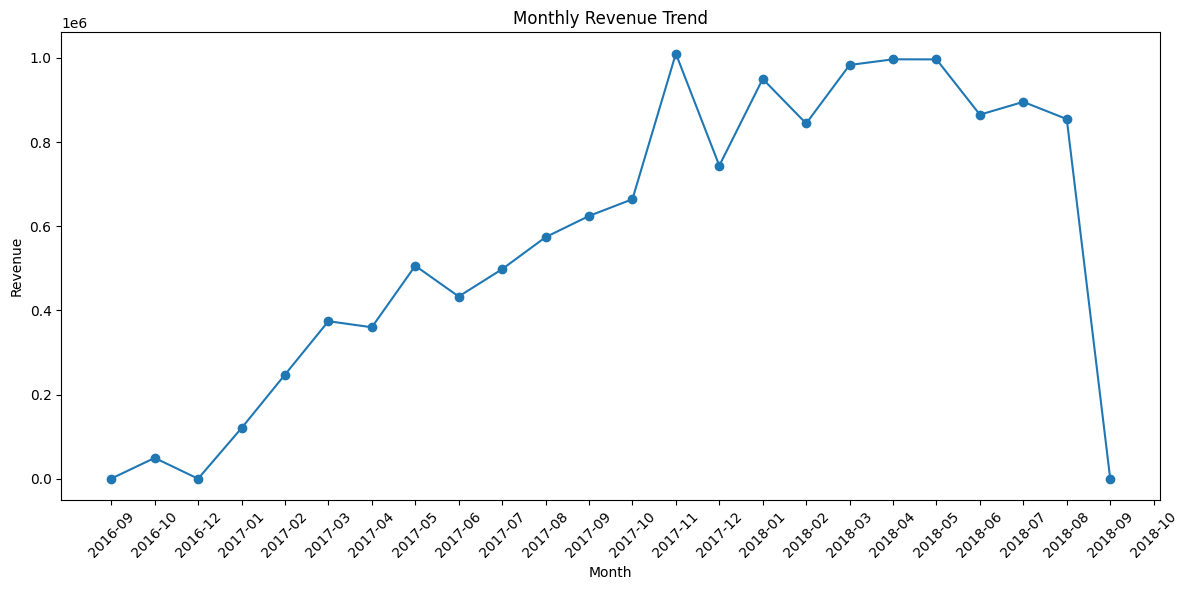

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales["purchase_month"],
    monthly_sales["revenue"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
top_revenue_months = (
    monthly_sales
    .sort_values("revenue", ascending=False)
    .head(10)
)

top_revenue_months

,purchase_month,total_orders,revenue,items_sold
13,2017-11,7544,1010271.37,8665.0
18,2018-04,6939,996647.75,7975.0
19,2018-05,6873,996517.68,7925.0
17,2018-03,7211,983213.44,8217.0
15,2018-01,7269,950030.36,8208.0
21,2018-07,6292,895507.22,7092.0
20,2018-06,6167,865124.31,7078.0
22,2018-08,6512,854686.33,7248.0
16,2018-02,6728,844178.71,7672.0
14,2017-12,5673,743914.17,6308.0


In [ ]:
customer_orders = (
    orders
    .groupby("customer_id")
    .agg(
        total_orders=("order_id", "nunique")
    )
    .reset_index()
)

In [ ]:
customer_orders.head(10)

,customer_id,total_orders
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1
5,0004164d20a9e969af783496f3408652,1
6,000419c5494106c306a97b5635748086,1
7,00046a560d407e99b969756e0b10f282,1
8,00050bf6e01e69d5c0fd612f1bcfb69c,1
9,000598caf2ef4117407665ac33275130,1


In [ ]:
customer_orders["customer_type"] = customer_orders["total_orders"].apply(
    lambda x: "Repeat Customer" if x > 1 else "One-Time Customer"
)

In [ ]:
customer_segments = (
    customer_orders
    .groupby("customer_type")
    .agg(
        customers=("customer_id", "count")
    )
    .reset_index()
)

customer_segments

,customer_type,customers
0,One-Time Customer,99441


In [ ]:
customer_segments["percentage"] = (
    customer_segments["customers"]
    / customer_segments["customers"].sum()
    * 100
).round(2)

customer_segments

,customer_type,customers,percentage
0,One-Time Customer,99441,100.0


In [ ]:
customer_revenue = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .groupby("customer_id")
    .agg(
        total_spend=("price", "sum"),
        total_items=("order_id", "count")
    )
    .reset_index()
)

In [ ]:
customer_revenue.head(10)

,customer_id,total_spend,total_items
0,00012a2ce6f8dcda20d059ce98491703,89.80,1
1,000161a058600d5901f007fab4c27140,54.90,1
2,0001fd6190edaaf884bcaf3d49edf079,179.99,1
3,0002414f95344307404f0ace7a26f1d5,149.90,1
4,000379cdec625522490c315e70c7a9fb,93.00,1
5,0004164d20a9e969af783496f3408652,59.99,1
6,000419c5494106c306a97b5635748086,34.30,1
7,00046a560d407e99b969756e0b10f282,120.90,1
8,00050bf6e01e69d5c0fd612f1bcfb69c,69.99,1
9,000598caf2ef4117407665ac33275130,1107.00,1


In [ ]:
top_customers = (
    customer_revenue
    .sort_values("total_spend", ascending=False)
    .head(10)
)

top_customers

,customer_id,total_spend,total_items
8475,1617b1357756262bfa56ab541c47bc16,13440.0,8
91284,ec5b2ba62e574342386871631fafd3fc,7160.0,4
76948,c6e2731c5b391845f6800c97401a43a9,6735.0,1
94398,f48d464a0baaea338cb25f816991ab1f,6729.0,1
24603,3fd6777bbce08a352fddd04e4a7cc8f6,6499.0,1
2049,05455dfa7cd02f13d132aa7a6a9729c6,5934.6,6
86248,df55c14d1476a9a3467f131269c2477f,4799.0,1
14182,24bbf5fd2f2e1b359ee7de94defc4a15,4690.0,1
86733,e0a2412720e9ea4f26c1ac985f6a7358,4599.9,2
23771,3d979689f636322c62418b6346b1c6d2,4590.0,1


In [ ]:
customer_revenue = (
    order_items
    .merge(
        orders[["order_id", "customer_id"]],
        on="order_id",
        how="left"
    )
    .groupby("customer_id")
    .agg(
        total_spend=("price", "sum"),
        total_items=("order_id", "count")
    )
    .reset_index()
)

In [ ]:
customer_revenue.head(10)

,customer_id,total_spend,total_items
0,00012a2ce6f8dcda20d059ce98491703,89.80,1
1,000161a058600d5901f007fab4c27140,54.90,1
2,0001fd6190edaaf884bcaf3d49edf079,179.99,1
3,0002414f95344307404f0ace7a26f1d5,149.90,1
4,000379cdec625522490c315e70c7a9fb,93.00,1
5,0004164d20a9e969af783496f3408652,59.99,1
6,000419c5494106c306a97b5635748086,34.30,1
7,00046a560d407e99b969756e0b10f282,120.90,1
8,00050bf6e01e69d5c0fd612f1bcfb69c,69.99,1
9,000598caf2ef4117407665ac33275130,1107.00,1


In [ ]:
top_customers = (
    customer_revenue
    .sort_values("total_spend", ascending=False)
    .head(10)
)

top_customers

,customer_id,total_spend,total_items
8475,1617b1357756262bfa56ab541c47bc16,13440.0,8
91284,ec5b2ba62e574342386871631fafd3fc,7160.0,4
76948,c6e2731c5b391845f6800c97401a43a9,6735.0,1
94398,f48d464a0baaea338cb25f816991ab1f,6729.0,1
24603,3fd6777bbce08a352fddd04e4a7cc8f6,6499.0,1
2049,05455dfa7cd02f13d132aa7a6a9729c6,5934.6,6
86248,df55c14d1476a9a3467f131269c2477f,4799.0,1
14182,24bbf5fd2f2e1b359ee7de94defc4a15,4690.0,1
86733,e0a2412720e9ea4f26c1ac985f6a7358,4599.9,2
23771,3d979689f636322c62418b6346b1c6d2,4590.0,1


In [ ]:
print(customer_revenue.shape)
print(customer_revenue.head())

(98666, 3)
                        customer_id  total_spend  total_items
0  00012a2ce6f8dcda20d059ce98491703        89.80            1
1  000161a058600d5901f007fab4c27140        54.90            1
2  0001fd6190edaaf884bcaf3d49edf079       179.99            1
3  0002414f95344307404f0ace7a26f1d5       149.90            1
4  000379cdec625522490c315e70c7a9fb        93.00            1


In [ ]:
top_customers = (
    customer_revenue
    .sort_values("total_spend", ascending=False)
    .head(10)
)

top_customers

,customer_id,total_spend,total_items
8475,1617b1357756262bfa56ab541c47bc16,13440.0,8
91284,ec5b2ba62e574342386871631fafd3fc,7160.0,4
76948,c6e2731c5b391845f6800c97401a43a9,6735.0,1
94398,f48d464a0baaea338cb25f816991ab1f,6729.0,1
24603,3fd6777bbce08a352fddd04e4a7cc8f6,6499.0,1
2049,05455dfa7cd02f13d132aa7a6a9729c6,5934.6,6
86248,df55c14d1476a9a3467f131269c2477f,4799.0,1
14182,24bbf5fd2f2e1b359ee7de94defc4a15,4690.0,1
86733,e0a2412720e9ea4f26c1ac985f6a7358,4599.9,2
23771,3d979689f636322c62418b6346b1c6d2,4590.0,1


In [ ]:
total_revenue = order_items["price"].sum()

total_orders = orders["order_id"].nunique()

total_customers = orders["customer_id"].nunique()

avg_order_value = total_revenue / total_orders

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Average Order Value:", round(avg_order_value, 2))

Total Revenue: 13591643.7
Total Orders: 99441
Total Customers: 99441
Average Order Value: 136.68


In [ ]:
top_customers = (
    customer_revenue
    .sort_values("total_spend", ascending=False)
    .head(10)
)

top_customers

,customer_id,total_spend,total_items
8475,1617b1357756262bfa56ab541c47bc16,13440.0,8
91284,ec5b2ba62e574342386871631fafd3fc,7160.0,4
76948,c6e2731c5b391845f6800c97401a43a9,6735.0,1
94398,f48d464a0baaea338cb25f816991ab1f,6729.0,1
24603,3fd6777bbce08a352fddd04e4a7cc8f6,6499.0,1
2049,05455dfa7cd02f13d132aa7a6a9729c6,5934.6,6
86248,df55c14d1476a9a3467f131269c2477f,4799.0,1
14182,24bbf5fd2f2e1b359ee7de94defc4a15,4690.0,1
86733,e0a2412720e9ea4f26c1ac985f6a7358,4599.9,2
23771,3d979689f636322c62418b6346b1c6d2,4590.0,1
